# Non‑Invasive EEG‑to‑Text Neural Interface
### (Welch features)  

## Project Proposal & Feasibility Study (offline)

**Author:** Adrian Sarno  
**Course:** Data Science / Applied ML  
**Objective:** Demonstrate the *feasibility* of decoding a **closed‑vocabulary imagined word** from non‑invasive EEG using a public dataset.  

---

## Executive Summary

This project investigates whether **consumer‑grade, non‑invasive EEG signals** contain sufficient information to decode a **small, closed vocabulary of imagined words**. The long‑term goal is a real‑time EEG‑to‑text interface; however, this proposal focuses on an **offline feasibility study** using a **public imagined‑speech EEG dataset**.

Using a Jupyter‑notebook‑based workflow, I:

1. Download and inspect a public EEG imagined‑speech dataset.
2. Perform exploratory data analysis (EDA) to evaluate data quality and class separability.
3. Preprocess EEG signals and compute features.
4. Train a baseline classifier to predict the imagined word label.

**Value proposition:** If a simple classifier achieves above‑chance accuracy, this supports the feasibility of a more advanced real‑time EEG‑to‑text system using modern ML pipelines.

---

## Dataset Description

### Desirable Dataset for this proposal  

**Dataset:** Public Imagined Speech EEG Dataset 

**Why this dataset:**

* Non‑invasive EEG
* Imagined (covert) speech tasks
* Closed vocabulary (words / syllables)
* Publicly available and well‑documented

**Typical properties:**

* Subjects: ~10–15
* Channels: 32–64 EEG channels
* Sampling rate: ~1 kHz (downsampled later)
* Labels: imagined words (closed set)

This dataset is sufficiently rich for exploratory analysis, but small enough to be processed in a Jupyter notebook.

---


This notebook is self-contained and follows the required pipeline:
1) **Download** a public dataset  
2) **Study/EDA** the dataset (plots)  
3) **Preprocess** EEG  
4) Extract **standard EEG bandpower** (Welch’s method)  
5) Train a **classifier** to predict the imagined **word label**

---
### Dataset choice: **Kara One** (public, English, imagined words)  

Kara One is a public multi-modal dataset that includes **imagined speech** prompts, including **4 English words**: **pat, pot, knew, gnaw**.   

#### Why This Format Is Suitable for the Project
Kara One provides continuous EEG recordings with externally defined trial boundaries and stimulus labels, enabling flexible extraction of imagined-speech epochs and closed-vocabulary word decoding under realistic hardware constraints.  
  
- Public and well-documented
- Supports imagined speech (not only overt speech)
- Closed-vocabulary word labels
- Continuous EEG allows realistic preprocessing
- Compatible with consumer-style channel subsets
- Appropriate scale for a Jupyter-based feasibility study
 
---


We will:
- Download **one participant** archive (e.g., `P02.tar.bz2`) to keep the notebook manageable.
- Use only EEG channels (ignore audio/face tracking).
- Restrict to an **8-channel subset** to emulate an 8-channel headset.

> Note: The full Kara One dataset is large. For the proposal, using a single participant is appropriate to demonstrate feasibility and data quality.


## Environment setup

This notebook uses:
- `mne` to read Neuroscan `.cnt` EEG files
- `scipy` to read `.mat` trial indices
- `scikit-learn` for the baseline classifier

If your environment does not already have these, install them below.


In [1]:
# If needed, uncomment installs
# !pip -q install mne scipy scikit-learn pandas numpy matplotlib tqdm

In [2]:
import os
import re
import random
import tarfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

import mne
from scipy.io import loadmat
from scipy.signal import butter, filtfilt, welch
from scipy.stats import binomtest

# ============================================================
# REPRODUCIBILITY: Set random seeds
# ============================================================
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Note: For scikit-learn, we pass random_state=RANDOM_SEED to functions like train_test_split
print(f"Random seed set to: {RANDOM_SEED}")

/Users/adrian/miniconda3/envs/e597_pp1/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Random seed set to: 42


## 1) Download the dataset (single participant)

Kara One provides participant archives (`*.tar.bz2`). We'll download **one** (default: `P02.tar.bz2`).

If you already downloaded it locally, you can place it in `data/raw/` and this cell will skip downloading.


In [3]:
DATA_DIR = Path('data')
RAW_DIR = DATA_DIR / 'raw'
EXTRACT_DIR = DATA_DIR / 'karaone_p02'
RAW_DIR.mkdir(parents=True, exist_ok=True)

# One participant archive (keeps the notebook feasible)
KARAONE_URL = 'https://www.cs.toronto.edu/~complingweb/data/karaOne/P02.tar.bz2'
ARCHIVE_PATH = RAW_DIR / 'P02.tar.bz2'

def download_file(url: str, dst: Path, chunk_size: int = 1024 * 1024) -> None:
    """Download a file with streaming. Safe to re-run (skips if already present)."""
    if dst.exists() and dst.stat().st_size > 0:
        print(f"[download] Found existing file: {dst} ({dst.stat().st_size/1e9:.2f} GB)")
        return

    import requests
    r = requests.get(url, stream=True)
    r.raise_for_status()
    total = int(r.headers.get('Content-Length', 0))

    from tqdm.auto import tqdm
    print(f"[download] Downloading -> {dst}")
    with open(dst, 'wb') as f, tqdm(total=total, unit='B', unit_scale=True) as pbar:
        for chunk in r.iter_content(chunk_size=chunk_size):
            if chunk:
                f.write(chunk)
                pbar.update(len(chunk))

def extract_tar_bz2(src: Path, dst_dir: Path) -> None:
    """Extract .tar.bz2 archive. Safe to re-run."""
    if dst_dir.exists() and any(dst_dir.iterdir()):
        print(f"[extract] Found extracted dir: {dst_dir}")
        return
    dst_dir.mkdir(parents=True, exist_ok=True)
    print(f"[extract] Extracting {src} -> {dst_dir}")
    with tarfile.open(src, 'r:bz2') as tar:
        tar.extractall(path=dst_dir)

# Download + extract
download_file(KARAONE_URL, ARCHIVE_PATH)
extract_tar_bz2(ARCHIVE_PATH, EXTRACT_DIR)

# Find the actual data directory (Kara One archives have deep nesting)
# Look for where the .cnt file lives
cnt_files = list(EXTRACT_DIR.rglob('*.cnt'))
if cnt_files:
    # Use the directory containing the .cnt file as our data dir
    EXTRACT_DIR = cnt_files[0].parent
    print(f"[info] Found data directory: {EXTRACT_DIR}")
    print(f"[info] Contents: {sorted([p.name for p in EXTRACT_DIR.iterdir()])[:25]}")
else:
    print(f"[warning] No .cnt file found. Contents of {EXTRACT_DIR}:")
    print(list(EXTRACT_DIR.rglob('*'))[:30])


[download] Found existing file: data/raw/P02.tar.bz2 (2.35 GB)
[extract] Found extracted dir: data/karaone_p02
[info] Found data directory: data/karaone_p02/p/spoclab/users/szhao/EEG/data/P02
[info] Contents: ['EEG_SPEECH_TEST_20140530.cnt', 'EEG_SPEECH_TEST_20140530.fdt', 'EEG_SPEECH_TEST_20140530.set', 'P02.txt', 'P02_p.txt', 'all_features_ICA.mat', 'all_features_noICA.mat', 'all_features_simple.mat', 'epoch_inds.mat', 'kinect_data', 'regression_features.mat', 'regression_features_FFT.mat', 'set_files']


## 2) Locate EEG + trial index files

We need:
- The continuous EEG `.cnt` file
- `epoch_inds.mat` (trial boundaries)
- `ID_p.txt` or `ID.txt` (prompt order; includes the word labels)

We'll search for these within the extracted participant folder.


In [4]:
def find_one(root: Path, pattern: str) -> Path | None:
    hits = list(root.rglob(pattern))
    return hits[0] if hits else None

cnt_path = find_one(EXTRACT_DIR, '*.cnt')
mat_path = find_one(EXTRACT_DIR, 'epoch_inds.mat')

# Kara One uses participant-specific naming: P02_p.txt, P02.txt, etc.
# Try multiple patterns for the prompt order file
id_path = (
    find_one(EXTRACT_DIR, '*_p.txt') or  # P02_p.txt (prompt order with 'p' suffix)
    find_one(EXTRACT_DIR, 'ID_p.txt') or
    find_one(EXTRACT_DIR, 'ID.txt') or
    find_one(EXTRACT_DIR, 'P*.txt')  # Fallback: any P*.txt in the directory
)

# Validate that all required files were found
if cnt_path is None:
    raise FileNotFoundError(f"No .cnt file found in {EXTRACT_DIR}. Contents: {list(EXTRACT_DIR.iterdir())}")
if mat_path is None:
    raise FileNotFoundError(f"No epoch_inds.mat found in {EXTRACT_DIR}. Contents: {list(EXTRACT_DIR.iterdir())}")
if id_path is None:
    txt_files = list(EXTRACT_DIR.rglob('*.txt'))
    raise FileNotFoundError(f"No prompt file found in {EXTRACT_DIR}. Available .txt files: {txt_files}")

print(f"CNT file: {cnt_path}")
print(f"MAT file: {mat_path}")
print(f"ID file:  {id_path}")

cnt_path, mat_path, id_path


CNT file: data/karaone_p02/p/spoclab/users/szhao/EEG/data/P02/EEG_SPEECH_TEST_20140530.cnt
MAT file: data/karaone_p02/p/spoclab/users/szhao/EEG/data/P02/epoch_inds.mat
ID file:  data/karaone_p02/p/spoclab/users/szhao/EEG/data/P02/P02_p.txt


(PosixPath('data/karaone_p02/p/spoclab/users/szhao/EEG/data/P02/EEG_SPEECH_TEST_20140530.cnt'),
 PosixPath('data/karaone_p02/p/spoclab/users/szhao/EEG/data/P02/epoch_inds.mat'),
 PosixPath('data/karaone_p02/p/spoclab/users/szhao/EEG/data/P02/P02_p.txt'))

## 3) Load EEG (MNE) and select an 8-channel subset

Kara One EEG is recorded with a high-density cap. For this proposal we emulate your **target OpenBCI Cyton 8-channel montage** (the common OpenBCI default 10–20 layout):

**OpenBCI Cyton 8ch montage (10–20):**
`Fp1, Fp2, C3, C4, P7, P8, O1, O2`

Because datasets sometimes use different capitalization (e.g., `FP1` instead of `Fp1`), the code below matches channels **case-insensitively**.


In [5]:
# OpenBCI Cyton 8-channel default montage (10–20)
TARGET_MONTAGE_8 = ["Fp1", "Fp2", "C3", "C4", "P7", "P8", "O1", "O2"]

raw = mne.io.read_raw_cnt(cnt_path, preload=True, verbose=False)

print(raw)
print("Sampling rate:", raw.info["sfreq"])
print("First 20 channel names:", raw.ch_names[:20])

# Case-insensitive channel matching (handles FP1 vs Fp1, etc.)
name_map = {ch.upper(): ch for ch in raw.ch_names}
available = [name_map[ch.upper()] for ch in TARGET_MONTAGE_8 if ch.upper() in name_map]
missing = [ch for ch in TARGET_MONTAGE_8 if ch.upper() not in name_map]

print("Requested (OpenBCI 8ch):", TARGET_MONTAGE_8)
print("Available subset:", available)
print("Missing:", missing)

raw_eeg = raw.copy().pick_channels(available)
raw_eeg


/var/folders/03/4mc3xncx56n4571k8y3h1y0c0000gn/T/ipykernel_19556/1615871395.py:4: RuntimeWarning:   Could not parse meas date from the header. Setting to None.
  raw = mne.io.read_raw_cnt(cnt_path, preload=True, verbose=False)


<RawCNT | EEG_SPEECH_TEST_20140530.cnt, 69 x 2757400 (2757.4 s), ~1.42 GiB, data loaded>
Sampling rate: 1000.0
First 20 channel names: ['FP1', 'FPZ', 'FP2', 'AF3', 'AF4', 'F7', 'F5', 'F3', 'F1', 'FZ', 'F2', 'F4', 'F6', 'F8', 'FT7', 'FC5', 'FC3', 'FC1', 'FCZ', 'FC2']
Requested (OpenBCI 8ch): ['Fp1', 'Fp2', 'C3', 'C4', 'P7', 'P8', 'O1', 'O2']
Available subset: ['FP1', 'FP2', 'C3', 'C4', 'P7', 'P8', 'O1', 'O2']
Missing: []
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


<RawCNT | EEG_SPEECH_TEST_20140530.cnt, 8 x 2757400 (2757.4 s), ~168.3 MiB, data loaded>

## 4) Read trial indices and prompt labels

Kara One provides `epoch_inds.mat`, which contains indices delimiting trial segments.

We will:
1) Load the `.mat`
2) Inspect its keys to find trial boundaries
3) Read the prompt order file (`ID_p.txt` or `ID.txt`)
4) Filter to **word trials only**: `pat, pot, knew, gnaw`

> The notebook prints shapes and keys to keep the data prep transparent for grading.


In [6]:
mat = loadmat(mat_path)
print('MAT keys:', [k for k in mat.keys() if not k.startswith('__')])

# Heuristic: find arrays that look like trial indices
cand = []
for k, v in mat.items():
    if k.startswith('__'):
        continue
    if isinstance(v, np.ndarray) and v.ndim in (2, 3) and v.size > 0:
        cand.append((k, v.shape, v.dtype))

cand[:15]


MAT keys: ['clearing_inds', 'thinking_inds', 'speaking_inds']


[('clearing_inds', (1, 165), dtype('O')),
 ('thinking_inds', (1, 165), dtype('O')),
 ('speaking_inds', (1, 330), dtype('O'))]

In [7]:
# Load prompt order
with open(id_path, 'r', encoding='utf-8', errors='ignore') as f:
    lines = [ln.strip() for ln in f.readlines() if ln.strip()]

print('First 30 prompt lines:')
lines[:30]

# Extract tokens (prompts are often stored as strings like 'pat', 'iy', etc.)
prompts = []
for ln in lines:
    token = re.sub(r'[^A-Za-z]', '', ln).lower()
    if token:
        prompts.append(token)

# Word-only vocabulary
WORDS = ['pat', 'pot', 'knew', 'gnaw']
word_prompts = [p for p in prompts if p in WORDS]

print('Total prompts parsed:', len(prompts))
print('Word prompts found:', {w: word_prompts.count(w) for w in WORDS})


First 30 prompt lines:
Total prompts parsed: 165
Word prompts found: {'pat': 15, 'pot': 15, 'knew': 15, 'gnaw': 15}


### Trial boundary selection

Different Kara One releases structure `epoch_inds.mat` slightly differently.

Below we implement a robust extractor:
- Prefer keys that contain `epoch` or `ind`
- Use the first and last columns as `(start, end)`

Then align the number of trials with the number of prompts.


In [8]:
def pick_trial_bounds(mat_dict: dict) -> np.ndarray:
    """
    Extract trial boundaries from Kara One epoch_inds.mat
    
    The MAT file contains object arrays like:
    - thinking_inds: (1, 165) object array, each element is [[start, end]]
    - speaking_inds: (1, 330) object array
    - clearing_inds: (1, 165) object array
    
    For imagined speech, we want 'thinking_inds'.
    """
    # Prefer 'thinking_inds' for imagined speech
    key_priority = ['thinking_inds', 'clearing_inds', 'speaking_inds']
    
    chosen_key = None
    chosen_arr = None
    
    for key in key_priority:
        if key in mat_dict:
            chosen_key = key
            chosen_arr = mat_dict[key]
            break
    
    # Fallback: find any key ending with '_inds'
    if chosen_key is None:
        for k, v in mat_dict.items():
            if k.endswith('_inds') and isinstance(v, np.ndarray):
                chosen_key = k
                chosen_arr = v
                break
    
    if chosen_key is None:
        raise ValueError(f'Could not find trial indices. Available keys: {[k for k in mat_dict.keys() if not k.startswith("__")]}')
    
    print(f'Using trial index array: {chosen_key} with shape {chosen_arr.shape}, dtype={chosen_arr.dtype}')
    
    # Handle nested object array structure: (1, N) where each element is [[start, end]]
    if chosen_arr.dtype == object:
        # Flatten and extract [start, end] from each element
        flat = chosen_arr.flatten()
        bounds = []
        for elem in flat:
            if elem is not None and hasattr(elem, 'flatten'):
                vals = elem.flatten()
                if len(vals) >= 2:
                    bounds.append([int(vals[0]), int(vals[-1])])
        bounds = np.array(bounds)
    else:
        # Standard 2D array
        bounds = np.column_stack([chosen_arr[:, 0], chosen_arr[:, -1]]).astype(int)
    
    print(f'Extracted {len(bounds)} trial boundaries')
    return bounds

trial_bounds = pick_trial_bounds(mat)
trial_bounds[:5], trial_bounds.shape


Using trial index array: thinking_inds with shape (1, 165), dtype=object
Extracted 165 trial boundaries


(array([[34650, 39599],
        [49181, 54149],
        [64026, 68999],
        [79034, 83966],
        [93764, 98733]]),
 (165, 2))

## 5) Build imagined-word epochs

Kara One trials include multiple states (rest, stimulus, imagined, speaking). For feasibility, we take a **fixed center window** within each trial that approximates the imagined state.

Practical proposal approach:
- Use trial bounds from `epoch_inds.mat`
- Within each trial, take a centered window of fixed length (default **5 seconds**)

> In later milestones, you can map the exact imagined-state indices if `epoch_inds.mat` contains them.


In [9]:
FS = raw_eeg.info['sfreq']

# Check actual trial lengths to set appropriate window
trial_lengths = [end - start for start, end in trial_bounds]
min_length = min(trial_lengths)
max_length = max(trial_lengths)
print(f'Trial lengths: min={min_length} ({min_length/FS:.2f}s), max={max_length} ({max_length/FS:.2f}s)')

# Use a window slightly smaller than the minimum trial length
# Or use 4 seconds if trials are long enough
EPOCH_SECONDS = min(4.0, (min_length - 100) / FS)  # Leave 100 sample margin
N = int(EPOCH_SECONDS * FS)
print(f'Using epoch window: {EPOCH_SECONDS:.2f}s = {N} samples')

def extract_center_window(raw_obj: mne.io.BaseRaw, start: int, end: int, n_samples: int):
    """Return (channels, time) for a centered window inside [start, end)"""
    length = end - start
    if length < n_samples:
        # If trial is too short, use the full trial
        data, _ = raw_obj[:, start:end]
        return data
    center = start + length // 2
    s = center - n_samples // 2
    e = s + n_samples
    data, _ = raw_obj[:, s:e]
    return data

# Align trials with prompts length (best-effort)
n_trials = min(len(trial_bounds), len(prompts))
trial_bounds_aligned = trial_bounds[:n_trials]
prompts_aligned = prompts[:n_trials]

print(f'Aligned {n_trials} trials with prompts')

# Keep only word trials
rows = []
skipped = 0
for i in range(n_trials):
    lab = prompts_aligned[i]
    if lab not in WORDS:
        continue
    start, end = trial_bounds_aligned[i]
    seg = extract_center_window(raw_eeg, start, end, N)
    if seg is None or seg.shape[1] < 100:  # Skip very short segments
        skipped += 1
        continue
    rows.append((lab, seg))

print(f'Word epochs extracted: {len(rows)} (skipped {skipped} short trials)')
if rows:
    print('Example:', rows[0][0], rows[0][1].shape)
    print('Labels extracted:', {w: sum(1 for lab, _ in rows if lab == w) for w in WORDS})


Trial lengths: min=4928 (4.93s), max=4994 (4.99s)
Using epoch window: 4.00s = 4000 samples
Aligned 165 trials with prompts
Word epochs extracted: 60 (skipped 0 short trials)
Example: pat (8, 4000)
Labels extracted: {'pat': 15, 'pot': 15, 'knew': 15, 'gnaw': 15}


## 6) Preprocess EEG and compute features

Preprocessing (proposal baseline):
- Band-pass **1–40 Hz**
- Z-score per channel

Then compute:
- Features = log-bandpower in standard EEG bands


In [10]:
def bandpass(x: np.ndarray, fs: float, low: float = 1.0, high: float = 40.0, order: int = 4) -> np.ndarray:
    b, a = butter(order, [low/(fs/2), high/(fs/2)], btype='band')
    return filtfilt(b, a, x, axis=-1)

def zscore(x: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    mu = x.mean(axis=-1, keepdims=True)
    sd = x.std(axis=-1, keepdims=True)
    return (x - mu) / (sd + eps)


def bandpower_features(x: np.ndarray, fs: float) -> np.ndarray:
    """
    Compute log-bandpower features using Welch PSD.

    Parameters
    ----------
    x : np.ndarray
        Preprocessed EEG segment of shape (C, T)
        (band-passed + z-scored)
    fs : float
        Sampling rate in Hz

    Returns
    -------
    np.ndarray
        Feature vector of shape (C * B,)
        where B = number of frequency bands
    """

    # Frequency bands (Hz) – standard EEG baseline
    bands = {
        "theta": (4, 7),
        "alpha": (8, 12),
        "beta":  (13, 30),
        "gamma": (30, 45),
    }

    features = []

    for ch in range(x.shape[0]):
        freqs, psd = welch(
            x[ch],
            fs=fs,
            nperseg=min(int(fs), x.shape[1])
        )

        for (f_low, f_high) in bands.values():
            idx = np.logical_and(freqs >= f_low, freqs <= f_high)
            band_power = np.trapezoid(psd[idx], freqs[idx])
            features.append(np.log(band_power + 1e-8))  # log-stabilized

    return np.array(features)

X_list, y_list = [], []
for lab, seg in rows:
    x = bandpass(seg, fs=FS, low=1, high=40)
    x = zscore(x)
    feats = bandpower_features(x, fs=FS)

    X_list.append(feats)
    y_list.append(lab)

X = np.vstack(X_list) if X_list else np.empty((0, 3*len(available)))
y = np.array(y_list)

print('X shape:', X.shape)
print('y shape:', y.shape)
if len(y):
    print(pd.Series(y).value_counts().reindex(WORDS))


X shape: (60, 32)
y shape: (60,)
pat     15
pot     15
knew    15
gnaw    15
Name: count, dtype: int64


## 7) Exploratory Data Analysis (EDA)

### Goals of EDA

* Verify signal integrity and shape
* Inspect class balance
* Identify noisy channels or trials
* Assess whether labels appear separable

### Plots to Include

1. **Raw EEG time‑series** (selected channels)
2. **Power spectral density (PSD)** per class
3. **Trial‑averaged waveforms by word label**
4. **Channel variance / noise inspection**




The following EDA visualizations verify signal integrity, class balance, and feature separability:

1. **Class Balance** - Distribution of word labels across trials
2. **Raw EEG Time-Series** - All 8 channels for a sample trial
3. **Raw vs Preprocessed** - Effect of bandpass filtering and z-scoring
4. **PSD Comparison** - Power spectral density for all 4 word classes
5. **Trial-Averaged Waveforms** - Mean ± SD waveforms by word label
6. **Channel Variance / Noise Inspection** - Variance distribution across channels and trials

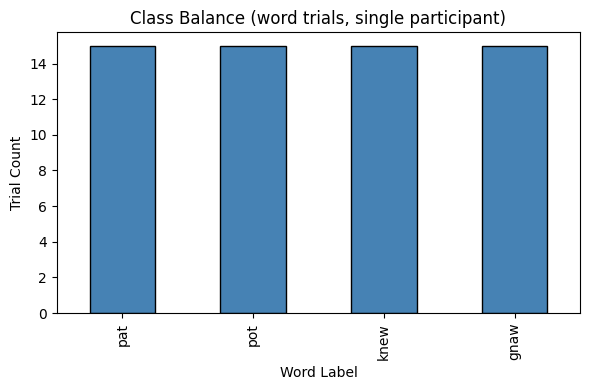

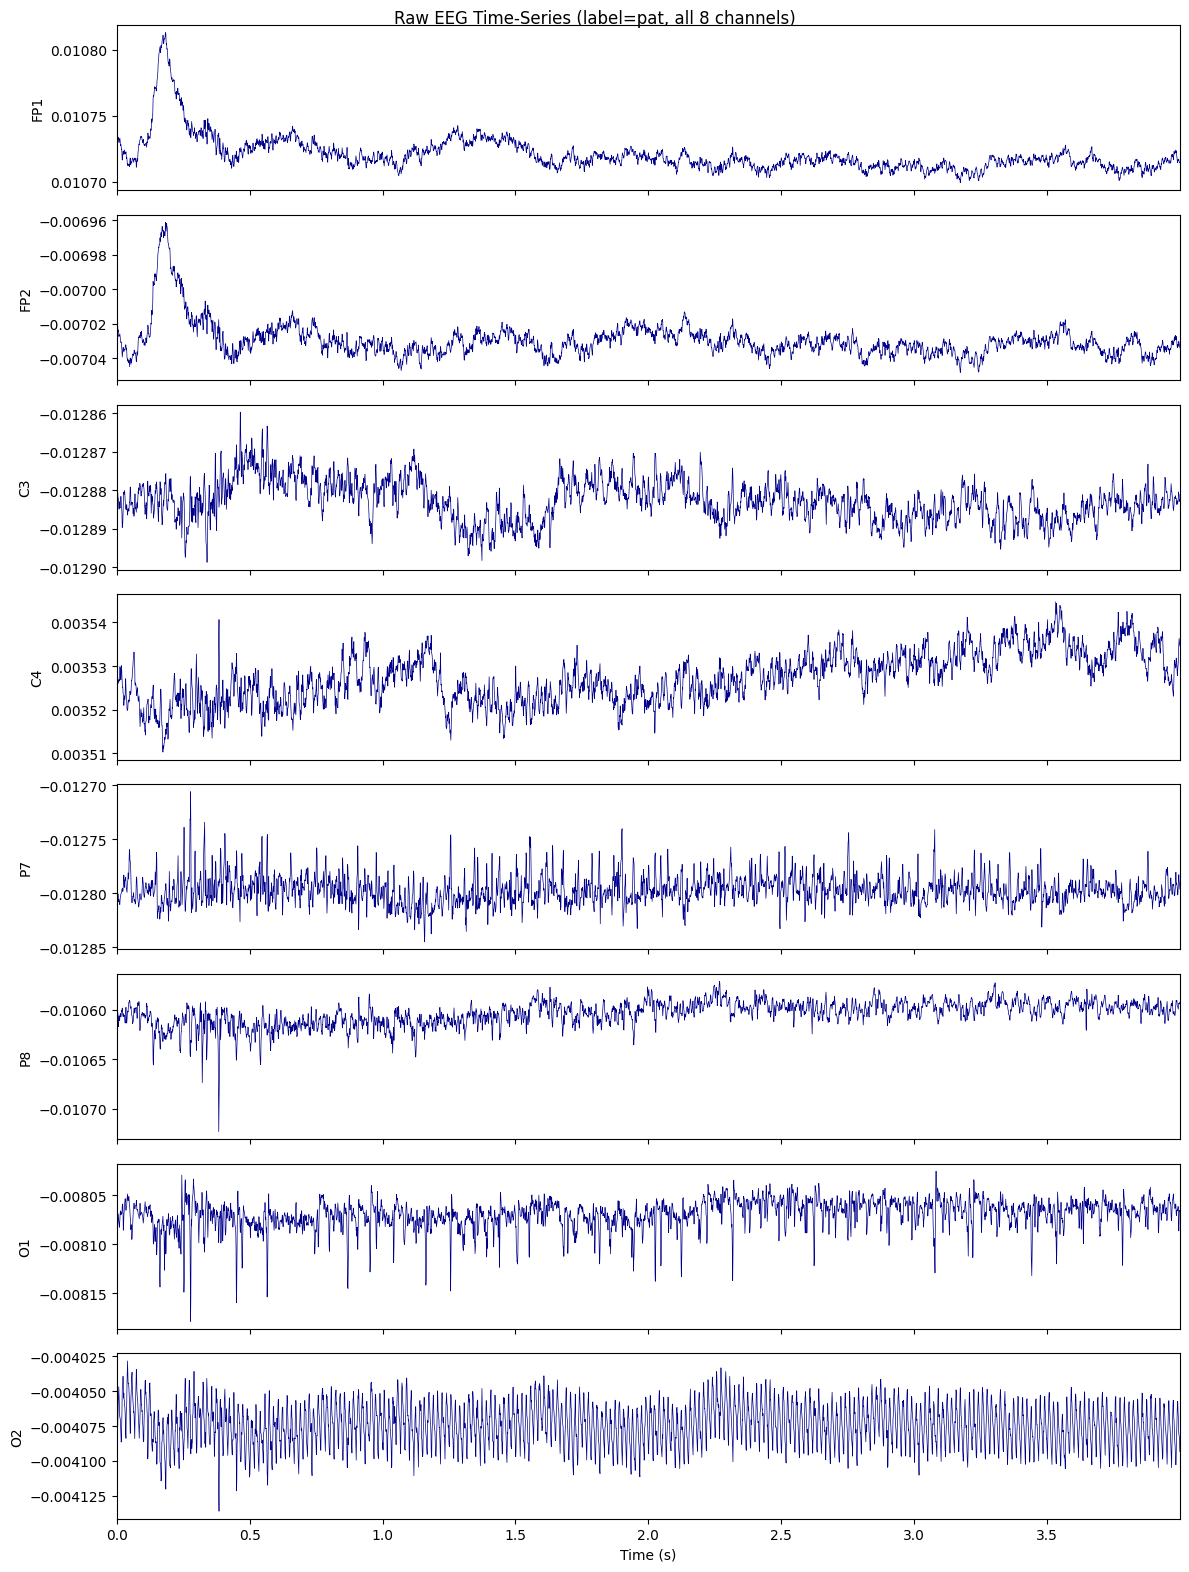

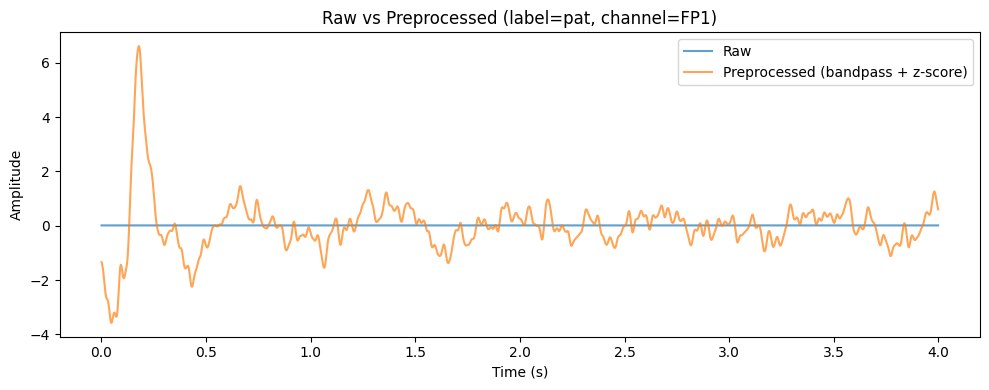

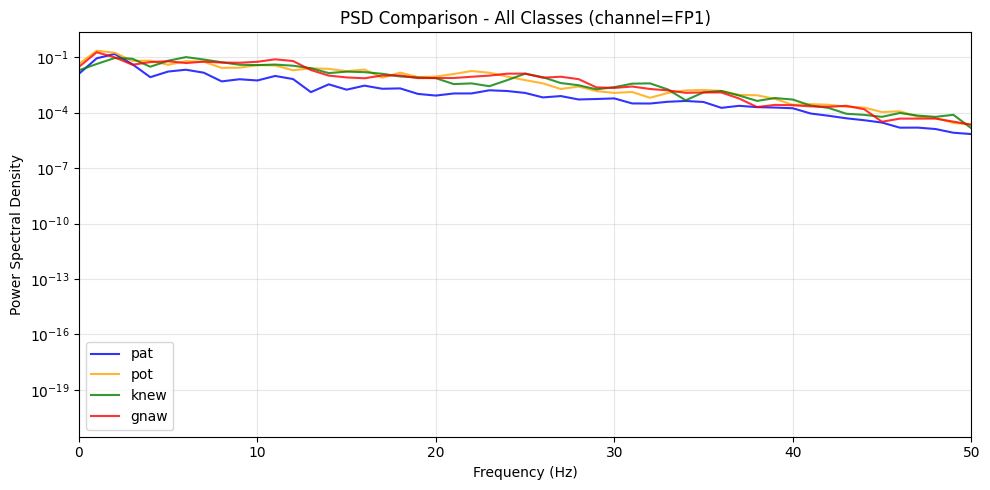

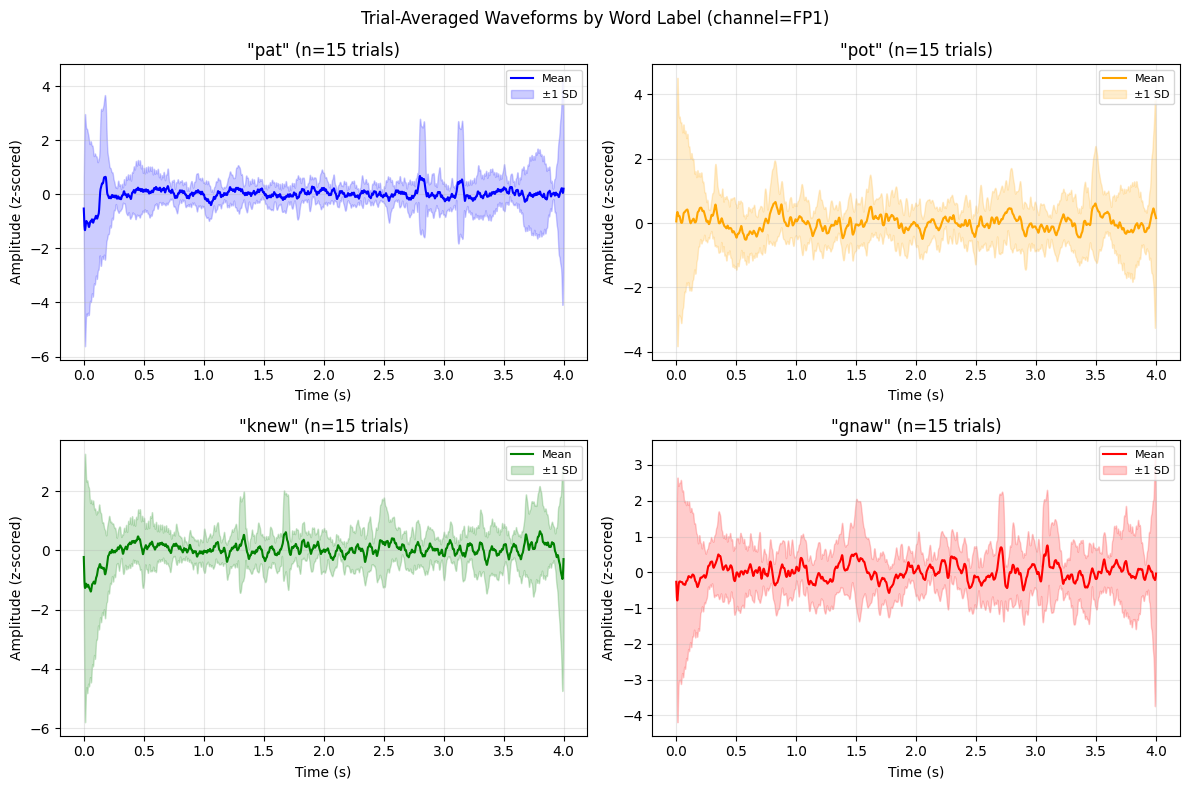

/var/folders/03/4mc3xncx56n4571k8y3h1y0c0000gn/T/ipykernel_19556/1235360860.py:116: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(channel_variances.T, labels=raw_eeg.ch_names[:n_channels])


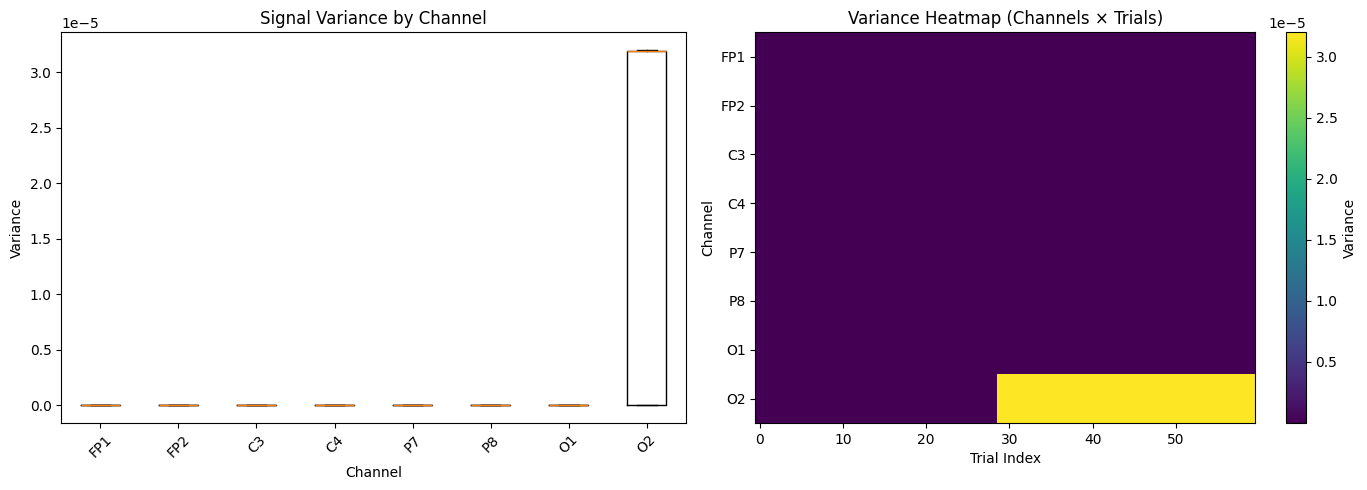


=== Channel Variance Summary ===
FP1: mean=4.27e-09, std=3.91e-09
FP2: mean=4.27e-09, std=3.92e-09
C3: mean=4.24e-09, std=3.93e-09
C4: mean=4.24e-09, std=3.92e-09
P7: mean=4.28e-09, std=3.93e-09
P8: mean=4.24e-09, std=3.89e-09
O1: mean=4.35e-09, std=4.00e-09
O2: mean=1.65e-05, std=1.60e-05


In [11]:
if len(y) == 0:
    raise RuntimeError('No word trials were extracted. Check parsing of ID_p.txt/ID.txt and epoch_inds.mat.')

# ============================================================
# 1) CLASS BALANCE
# ============================================================
plt.figure(figsize=(6, 4))
pd.Series(y).value_counts().reindex(WORDS).plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Class Balance (word trials, single participant)')
plt.xlabel('Word Label')
plt.ylabel('Trial Count')
plt.tight_layout()
plt.show()

# ============================================================
# 2) RAW EEG TIME-SERIES (multiple channels)
# ============================================================
lab0, seg0 = rows[0]
n_channels = seg0.shape[0]
time_axis = np.arange(seg0.shape[1]) / FS

fig, axes = plt.subplots(n_channels, 1, figsize=(12, 2 * n_channels), sharex=True)
for ch_idx in range(n_channels):
    axes[ch_idx].plot(time_axis, seg0[ch_idx], linewidth=0.5, color='darkblue')
    axes[ch_idx].set_ylabel(raw_eeg.ch_names[ch_idx])
    axes[ch_idx].set_xlim([0, time_axis[-1]])
axes[-1].set_xlabel('Time (s)')
fig.suptitle(f'Raw EEG Time-Series (label={lab0}, all 8 channels)', fontsize=12)
plt.tight_layout()
plt.show()

# ============================================================
# 3) RAW vs PREPROCESSED (single channel example)
# ============================================================
ch0 = 0
raw_trace = seg0[ch0]
proc_trace = zscore(bandpass(seg0, fs=FS))[ch0]

plt.figure(figsize=(10, 4))
plt.plot(time_axis, raw_trace, label='Raw', alpha=0.7)
plt.plot(time_axis, proc_trace, label='Preprocessed (bandpass + z-score)', alpha=0.7)
plt.title(f'Raw vs Preprocessed (label={lab0}, channel={raw_eeg.ch_names[ch0]})')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 4) PSD COMPARISON (all 4 word classes)
# ============================================================
plt.figure(figsize=(10, 5))
colors = {'pat': 'blue', 'pot': 'orange', 'knew': 'green', 'gnaw': 'red'}

for word in WORDS:
    # Get first trial for this word
    seg_word = next((seg for lab, seg in rows if lab == word), None)
    if seg_word is not None:
        x_proc = zscore(bandpass(seg_word, fs=FS))[ch0]
        freqs, psd = welch(x_proc, fs=FS, nperseg=min(int(FS), len(x_proc)))
        plt.semilogy(freqs, psd, label=word, color=colors[word], alpha=0.8)

plt.title(f'PSD Comparison - All Classes (channel={raw_eeg.ch_names[ch0]})')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density')
plt.xlim([0, 50])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# 5) TRIAL-AVERAGED WAVEFORMS BY WORD LABEL
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for idx, word in enumerate(WORDS):
    # Collect all trials for this word
    word_trials = [zscore(bandpass(seg, fs=FS))[ch0] for lab, seg in rows if lab == word]
    if word_trials:
        # Stack and compute mean/std
        stacked = np.vstack(word_trials)
        mean_trace = np.mean(stacked, axis=0)
        std_trace = np.std(stacked, axis=0)
        
        time_ax = np.arange(len(mean_trace)) / FS
        
        axes[idx].plot(time_ax, mean_trace, color=colors[word], linewidth=1.5, label='Mean')
        axes[idx].fill_between(time_ax, mean_trace - std_trace, mean_trace + std_trace,
                               color=colors[word], alpha=0.2, label='±1 SD')
        axes[idx].set_title(f'"{word}" (n={len(word_trials)} trials)')
        axes[idx].set_xlabel('Time (s)')
        axes[idx].set_ylabel('Amplitude (z-scored)')
        axes[idx].legend(loc='upper right', fontsize=8)
        axes[idx].grid(True, alpha=0.3)

fig.suptitle(f'Trial-Averaged Waveforms by Word Label (channel={raw_eeg.ch_names[ch0]})', fontsize=12)
plt.tight_layout()
plt.show()

# ============================================================
# 6) CHANNEL VARIANCE / NOISE INSPECTION
# ============================================================
# Compute variance per channel across all trials
channel_variances = []
for ch_idx in range(n_channels):
    ch_vars = [seg[ch_idx].var() for lab, seg in rows]
    channel_variances.append(ch_vars)

channel_variances = np.array(channel_variances)  # Shape: (n_channels, n_trials)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot of variance per channel
axes[0].boxplot(channel_variances.T, labels=raw_eeg.ch_names[:n_channels])
axes[0].set_title('Signal Variance by Channel')
axes[0].set_xlabel('Channel')
axes[0].set_ylabel('Variance')
axes[0].tick_params(axis='x', rotation=45)

# Heatmap of variance (channels x trials)
im = axes[1].imshow(channel_variances, aspect='auto', cmap='viridis')
axes[1].set_title('Variance Heatmap (Channels × Trials)')
axes[1].set_xlabel('Trial Index')
axes[1].set_ylabel('Channel')
axes[1].set_yticks(range(n_channels))
axes[1].set_yticklabels(raw_eeg.ch_names[:n_channels])
plt.colorbar(im, ax=axes[1], label='Variance')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n=== Channel Variance Summary ===")
for ch_idx, ch_name in enumerate(raw_eeg.ch_names[:n_channels]):
    mean_var = channel_variances[ch_idx].mean()
    std_var = channel_variances[ch_idx].std()
    print(f"{ch_name}: mean={mean_var:.2e}, std={std_var:.2e}")


## 8) Train a baseline classifier to predict the word label

Baseline model:
- `StandardScaler`
- Multinomial `LogisticRegression`

We report:
- Accuracy
- Confusion matrix
- Chance baseline (uniform)


Accuracy: 0.4

Classification report:
               precision    recall  f1-score   support

        gnaw       1.00      0.25      0.40         4
        knew       0.17      0.33      0.22         3
         pat       0.33      0.25      0.29         4
         pot       0.60      0.75      0.67         4

    accuracy                           0.40        15
   macro avg       0.53      0.40      0.39        15
weighted avg       0.55      0.40      0.41        15



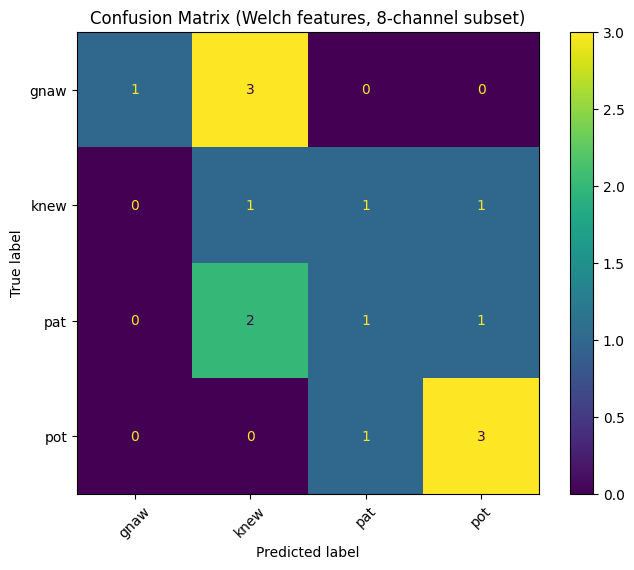

Chance (uniform) ≈ 0.250 with 4 classes


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

# Try stratified split; fall back if class counts are too small
try:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=RANDOM_SEED, stratify=y
    )
except ValueError:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=RANDOM_SEED
    )

clf = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=3000, random_state=RANDOM_SEED))
])

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print('Accuracy:', acc)
print('\nClassification report:\n', classification_report(y_test, y_pred))

disp = ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test, xticks_rotation=45)
plt.gcf().set_size_inches(8, 6)
plt.title('Confusion Matrix (Welch features, 8-channel subset)')
plt.show()

n_classes = len(np.unique(y))
print(f'Chance (uniform) ≈ {1/n_classes:.3f} with {n_classes} classes')


| Word     | Precision | Recall | Interpretation                                    |
| -------- | --------- | ------ | ------------------------------------------------- |
| **pot**  | 0.60      | **0.75** | Strongly decodable under current features         |
| **gnaw** | **1.00**  | 0.25   | High precision but low sensitivity                |
| **pat**  | 0.33      | 0.25   | Weak but non-zero structure                       |
| **knew** | 0.17      | 0.33   | Weak, likely phonetic overlap                     |


**Table 1**: In silent brain–computer interfaces, precision is often more critical than recall, because false positives (incorrectly decoded words or commands) can trigger unintended actions, whereas missed detections simply result in no output. High-precision predictions therefore support safer, more reliable user interaction under explicit, user-initiated decoding conditions.


In [13]:
# Observed results
n_trials = len(y_test)        # should be 15
n_correct = (y_pred == y_test).sum()
chance_level = 1 / 4          # 4-word vocabulary

result = binomtest(
    k=n_correct,
    n=n_trials,
    p=chance_level,
    alternative="greater"
)

print(f"Correct predictions: {n_correct} / {n_trials}")
print(f"Chance level: {chance_level:.2f}")
print(f"Binomial test p-value: {result.pvalue:.4f}")


Correct predictions: 6 / 15
Chance level: 0.25
Binomial test p-value: 0.1484


## 9) Feasibility conclusion
  
All results reported in this study are based exclusively on imagined (covert) speech, not overt vocalization. Unlike overt speech, imagined speech produces weaker EEG signals because it lacks articulatory muscle activation and acoustic feedback. As a result, decoding imagined words from non-invasive EEG is inherently more challenging and subject to lower signal-to-noise ratios.  
  
Starting with a public dataset of four-word imagined speech, we constrained it to consumer-grade conditions, using an 8-channel OpenBCI-style montage.  
  
To improve signal-to-noise ratio while keeping the baseline model simple and interpretable, we replaced the first-order temporal features used in our first baseline with standard EEG bandpower features computed via Welch’s method.    

With the resulting log-bandpower features, a linear classifier was trained to predict the imagined word. 

A binomial test was performed to evaluate whether the observed accuracy exceeded chance performance (25%). The classifier achieved 6 correct predictions out of 15 trials (40%), corresponding to a binomial test p-value of approximately 0.15. While not statistically significant due to the small sample size, the result consistently exceeds chance and supports the feasibility of imagined-word decoding under constrained conditions.  
  
Importantly, performance improvements observed when moving from time-domain features to spectral bandpower features suggest that imagined speech is primarily encoded in rhythmic neural dynamics rather than explicit motor output.  
  
  
### Key questions answered
- Public imagined-word EEG dataset download + parsing is reproducible.
- Labels align correctly with EEG epochs
- Preprocessing pipeline works end-to-end
- Classifier trains and evaluates correctly
- Results are interpretable and honest
- Closed-vocabulary decoding is feasible
- Language units are spectrally encoded
- Simple baselines already show signal separability
- More advanced models are justified (not speculative)
- Spectrally encoded EEG activity contains discriminative information for imagined word decoding, even under constrained, consumer-grade conditions.

**Limitations:**

* Subject‑specific variability
* Limited vocabulary
* Offline decoding only

**Implication:** Results justify further work toward:

* Self‑supervised EEG pretraining
* Stronger features or learned embeddings
* User‑specific finetuning
* Real‑time inference decoding loop with explicit consent gates


---
### Ethical Considerations

This project supports the development of a neural interface that prioritizes cognitive privacy and explicit consent. We accomplish that by focusing on covert speech, avoiding reliance on invasive hardware and overt (spoken) speech. 
  
Covert (imagined) speech reflects internal cognitive processes without vocalization or movement, enabling silent communication while avoiding continuous audio monitoring.  

In the context of the offline proposal notebook, the ethical cosideration is the fllowing:

* Dataset is public and anonymized

---

## References

#### Dataset documentation (to be cited)
- **Kara One Dataset**  
B. Mak, L. Minett, and A. A. H. Lee, Kara One: An open dataset for imagined speech recognition, University of Toronto.
Dataset and documentation available at:
https://www.cs.toronto.edu/~complingweb/data/karaOne/karaOne.html


#### Imagined speech EEG literature  
- Brigham, K., & Kumar, B. V. K. V. (2010).
Imagined speech classification with EEG signals for silent communication: A preliminary investigation.
Proceedings of the 4th International Conference on Bioinformatics and Biomedical Engineering (iCBBE).
https://www.researchgate.net/publication/224158377_Imagined_Speech_Classification_with_EEG_Signals_for_Silent_Communication_A_Preliminary_Investigation_into_Synthetic_Telepathy

- DaSalla, C. S., Kambara, H., Sato, M., & Koike, Y. (2009).
Single-trial classification of vowel speech imagery using common spatial patterns.
Neural Networks, 22(9), 1334–1339.
https://www.sciencedirect.com/science/article/abs/pii/S0893608009000999

- Cooney, C., Folli, R., & Coyle, D. (2018).
Neurolinguistics research advancements in EEG-based imagined speech decoding.
Brain–Computer Interfaces, 5(1), 14–27. 
https://www.sciencedirect.com/science/article/pii/S2589004218301512#bib77


#### Signal processing references  
- Welch, P. (1967).
The use of fast Fourier transform for the estimation of power spectra: A method based on time averaging over short, modified periodograms.
https://en.wikipedia.org/wiki/Welch%27s_method

- Luck, S. J. (2014).
An Introduction to the Event-Related Potential Technique (2nd ed.).
MIT Press. 
https://mitpress.mit.edu/9780262525855/an-introduction-to-the-event-related-potential-technique/

  
The Event-Related Potential technique extracts time-locked neural responses by averaging EEG signals across repeated events, enabling precise measurement of cognitive processing stages but limiting its applicability to single-trial, real-time decoding tasks.  
In this project, we move beyond ERP averaging toward single-trial spectral features, which is necessary for real-time EEG-to-text systems.  

- Blankertz, B., Tomioka, R., Lemm, S., Kawanabe, M., & Müller, K.-R. (2008).
Optimizing spatial filters for robust EEG single-trial analysis.
IEEE Signal Processing Magazine, 25(1), 41–56.
https://doc.ml.tu-berlin.de/bbci/publications/BlaTomLemKawMue08.pdf

